<a href="https://colab.research.google.com/github/ddecry/analise_dados_atvs/blob/main/C%C3%B3pia_de_Atividade_3_Simula%C3%A7%C3%A3o_de_Monte_Carlo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Simulação de Monte Carlo - Caso TechToy**
1. **Introdução e Contexto**

A empresa TechToy está prestes a lançar um novo drone no mercado. A diretoria está em dúvida entre duas estratégias de lançamento e contratou você, analista de dados, para realizar uma Simulação de Monte Carlo.

O objetivo é entender não apenas o lucro esperado, mas o risco de prejuízo de cada decisão.

As Estratégias:
Estratégia A (Conservadora): Foca em um público de nicho, com preço mais alto e vendas mais previsíveis.

Estratégia B (Agressiva): Foca em escala, com preço menor, mas com custos de produção e volume de vendas muito mais incertos.

**2. Base de Dados e Parâmetros**

Execute a célula abaixo para carregar as bibliotecas necessárias e os parâmetros oficiais fornecidos pelo departamento financeiro.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Configurações da Simulação
N_SIMULACOES = 10000

# --- PARÂMETROS ESTRATÉGIA A ---
vendas_media_a = 500
vendas_desvio_a = 50
custo_min_a = 600
custo_max_a = 700
preco_venda_a = 1200
investimento_fixo_a = 50000

# --- PARÂMETROS ESTRATÉGIA B ---
vendas_media_b = 800
vendas_desvio_b = 250
custo_min_b = 400
custo_max_b = 800
preco_venda_b = 1000
investimento_fixo_b = 150000

print("Parâmetros carregados com sucesso!")

Parâmetros carregados com sucesso!


3. Desafio

**1: Modelagem do Lucro**

Crie uma função ou um script que utilize os parâmetros acima para gerar 10.000 resultados possíveis de lucro para cada estratégia.Dicas:Para as Vendas, use uma distribuição Normal: np.random.normal(media, desvio, N_SIMULACOES).Para o Custo Unitário, use uma distribuição Uniforme: np.random.uniform(min, max, N_SIMULACOES).

A fórmula do lucro é:

$Lucro = (Vendas \times Preço) - (Vendas \times Custo\_Unitário) - Investimento\_Fixo$

In [4]:
# 1) Modelagem do Lucro (Monte Carlo)

vendas_a = np.random.normal(vendas_media_a, vendas_desvio_a, N_SIMULACOES)
vendas_b = np.random.normal(vendas_media_b, vendas_desvio_b, N_SIMULACOES)

vendas_a = np.maximum(vendas_a, 0)
vendas_b = np.maximum(vendas_b, 0)

custo_unitario_a = np.random.uniform(custo_min_a, custo_max_a, N_SIMULACOES)
custo_unitario_b = np.random.uniform(custo_min_b, custo_max_b, N_SIMULACOES)

lucro_a = (vendas_a * preco_venda_a) - (vendas_a * custo_unitario_a) - investimento_fixo_a
lucro_b = (vendas_b * preco_venda_b) - (vendas_b * custo_unitario_b) - investimento_fixo_b

print("Simulação concluída! Lucros gerados para as duas estratégias.")

Simulação concluída! Lucros gerados para as duas estratégias.


**2: Visualização dos Resultados**

Gere um histograma comparando as duas estratégias. O gráfico deve ajudar a diretoria a visualizar onde o lucro se concentra e onde estão os riscos de perda (valores abaixo de zero).

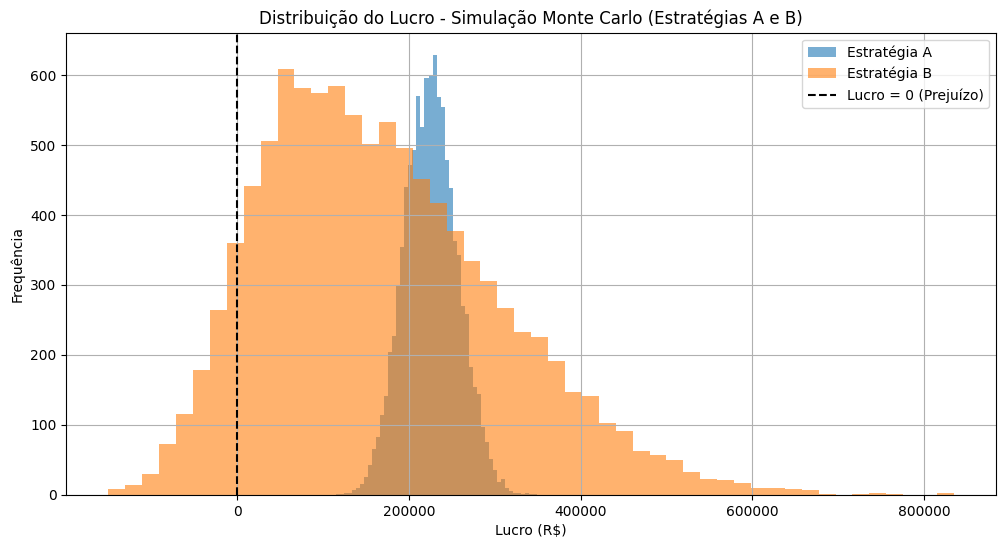

In [5]:
# 2) Visualização dos Resultados - Histograma comparando as duas estratégias

plt.figure(figsize=(12, 6))
plt.hist(lucro_a, bins=50, alpha=0.6, label="Estratégia A")
plt.hist(lucro_b, bins=50, alpha=0.6, label="Estratégia B")
plt.axvline(0, color="black", linestyle="--", label="Lucro = 0 (Prejuízo)")
plt.title("Distribuição do Lucro - Simulação Monte Carlo (Estratégias A e B)")
plt.xlabel("Lucro (R$)")
plt.ylabel("Frequência")
plt.legend()
plt.grid(True)

plt.show()

**3: Cálculo de Probabilidades**
Calcule e exiba as seguintes métricas para cada estratégia:

Média de Lucro.

Probabilidade de Prejuízo (porcentagem de simulações onde o lucro foi < 0).

In [6]:
# 3) Cálculo de Probabilidades

media_lucro_a = np.mean(lucro_a)
media_lucro_b = np.mean(lucro_b)
prob_prejuizo_a = np.mean(lucro_a < 0) * 100
prob_prejuizo_b = np.mean(lucro_b < 0) * 100

print("===== MÉTRICAS DAS ESTRATÉGIAS =====\n")
print("Estratégia A:")
print(f"Média de Lucro: R$ {media_lucro_a:,.2f}")
print(f"Probabilidade de Prejuízo: {prob_prejuizo_a:.2f}%\n")

print("Estratégia B:")
print(f"Média de Lucro: R$ {media_lucro_b:,.2f}")
print(f"Probabilidade de Prejuízo: {prob_prejuizo_b:.2f}%")

===== MÉTRICAS DAS ESTRATÉGIAS =====

Estratégia A:
Média de Lucro: R$ 225,502.89
Probabilidade de Prejuízo: 0.00%

Estratégia B:
Média de Lucro: R$ 168,180.57
Probabilidade de Prejuízo: 9.02%
